<!-- SPDX-FileCopyrightText: 2026 Orbital Research Cluster for Celestial Applications (ORCCA) Lab, University of Colorado at Boulder -->
<!-- SPDX-License-Identifier: ISC -->
# N-Plate Model and Spacecraft Attitude
---
*Scarabaeus | Last revised 2026*

## What this notebook covers
Two tightly related topics: the **N-Plate SRP model** which requires attitude data from
SPICE C-kernels to orient solar array panels, and the **spacecraft attitude** interface
used to extract orientation quaternions directly from C-kernels.
Both are demonstrated using the OSIRIS-REx mission.

### Topics
| # | Topic |
|---|-------|
| 1 | N-Plate Model — construction from a configuration file |
| 2 | N-Plate Model — examining CK panel intervals |
| 3 | N-Plate Model — querying time-varying normal vectors |
| 4 | N-Plate Model — static normals and spacecraft integration |
| 5 | Spacecraft Attitude — quaternion history from a C-kernel |

## How to run
Run from the **project root** directory (`scarabaeus/`).

## 0. Imports and Setup

In [1]:
import scarabaeus as scb
import supplementary as supp

from pathlib import Path
import numpy as np

# load tutorial data
data = supp.load_data()

# define units and fraes
km, hr, sec, kg = scb.Units.get_units(['km', 'hr', 'sec', 'kg'])
J2000 = scb.Frame('J2000')

# ── kernel pool (SC body CK + solar array CK + ephemeris) ─────────
scb.SpiceManager.clear_kernels()
scb.SpiceManager.load_kernel_from_mkfile(data.OREx_mk.path)

SCB supplementary data up to date.


---
## 1. N-Plate Model

The **N-Plate SRP model** represents a spacecraft's solar-radiation-pressure geometry
as a finite set of flat plates, each with its own area, reflectivity coefficients, and
surface normal.  Panels can be **fixed** in the spacecraft body frame or **attitude-driven**
by a SPICE C-kernel (CK), as is the case for articulated solar arrays.

The model is constructed from a JSON configuration file that specifies each panel's
physical properties and SPICE frame ID.  The two meta-kernel types loaded above are:

| Kernel type | Purpose |
|---|---|
| CK (spacecraft body) | Main-bus attitude → body-frame orientation in J2000 |
| CK (solar arrays) | Solar-panel articulation → time-varying panel normals |

### Constructing the Model

### Examining CK Panel Intervals

`SpiceManager.ckbrief` inspects a binary C-kernel and returns the SPICE frame IDs and
their valid time intervals.  The N-plate configuration defines panels `-64017` and `-64027`
(OSIRIS-REx solar arrays), which are plates 3 and 4 in the CK.  Both share the same interval,
so we take the first entry to get the query bounds.

In [2]:
# ── build N-plate model from configuration JSON ───────────────────
n_model = scb.nPlateModel(data.OREx_nplate.path)
print(n_model)

N-Plate Model containing 4 plates


### Querying Time-Varying Normal Vectors

`nPlateModel._get_ck_normals(epoch, sc_id)` returns the inertially-expressed unit normals
for all CK-driven panels at a given epoch.  `sc_id` is the spacecraft NAIF ID needed to
convert the epoch to spacecraft-clock ticks (SCLK) internally.

In [3]:
# ── inspect C-kernel for solar array panel intervals ─────────────
brief  = scb.SpiceManager.ckbrief(data.OREx_ck_sa.path, disp=True)

# panels -64017 and -64027 share the same valid interval → take first entry
plate4 = brief[0]
start, end = plate4['TDB_INTERVAL'][0][0], plate4['TDB_INTERVAL'][0][1]
print(f"\nQuery interval:  {start}  →  {end}")

       Brief orx_sa_rel_210816_210822_v02.bc        
ID: -64027
Interval (SCLK): 44718041024704.29 - 44757784483737.375
Interval (TDB): 682343306.1574311 sec (TDB) - 682949743.587035 sec (TDB)

ID: -64022
Interval (SCLK): 44718041024704.29 - 44757784483737.375
Interval (TDB): 682343306.1574311 sec (TDB) - 682949743.587035 sec (TDB)

ID: -64017
Interval (SCLK): 44718041024704.29 - 44757784483737.375
Interval (TDB): 682343306.1574311 sec (TDB) - 682949743.587035 sec (TDB)

ID: -64012
Interval (SCLK): 44718041024704.29 - 44757784483737.375
Interval (TDB): 682343306.1574311 sec (TDB) - 682949743.587035 sec (TDB)


Query interval:  682343306.1574311 sec (TDB)  →  682949743.587035 sec (TDB)


The plot below shows how the two solar-array normals (`ORX_SA_PY_IG` and `ORX_SA_NY_IG`)
rotate over the queried interval.  The interactive version lets you scrub through time;
the inline version renders statically for documentation.

In [4]:
# ── query CK normals every half-hour across the full interval ─────
orex_id = -64                                          # NAIF SC ID for SCLK
dt      = scb.ArrayWUnits(0.5, hr)
times   = scb.EpochArray.interval(start.to(rep = 'NUM'), end.to(rep ='NUM'), dt)

normals = [n_model._get_ck_normals(t, orex_id) for t in times]
print(f"{len(normals)} epochs queried,  {len(normals[0])} CK panels per epoch")

337 epochs queried,  2 CK panels per epoch


### Plotting Normal Vectors

> **Note:** `%matplotlib widget` makes the figure interactive (time slider).

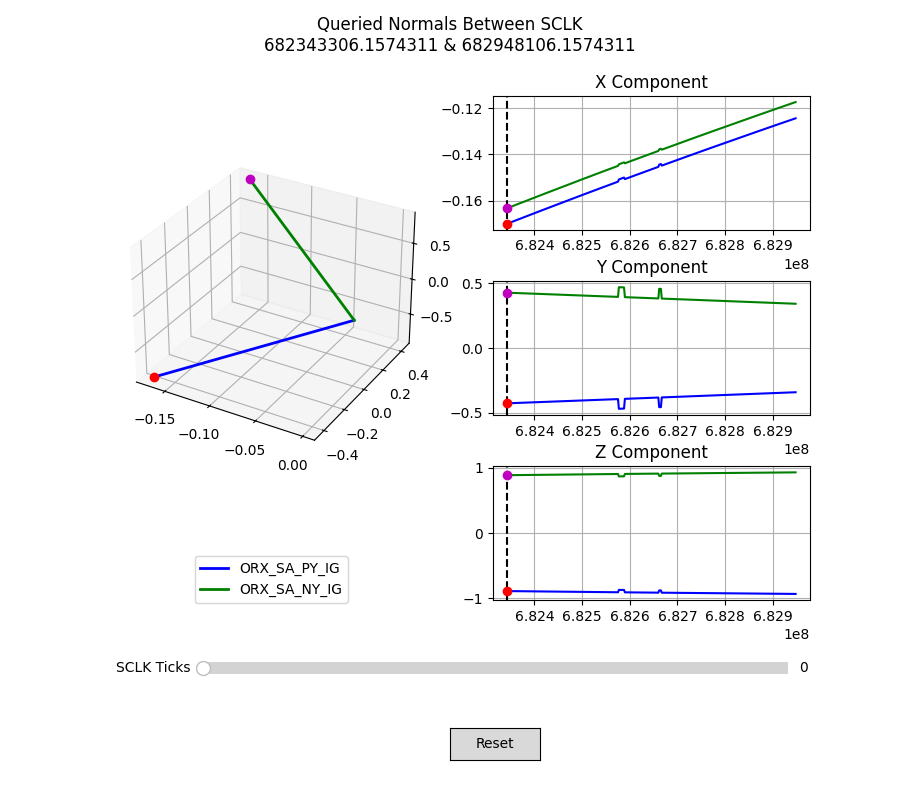

In [5]:
%matplotlib widget
supp.plotting.plot_normals(normals, times)

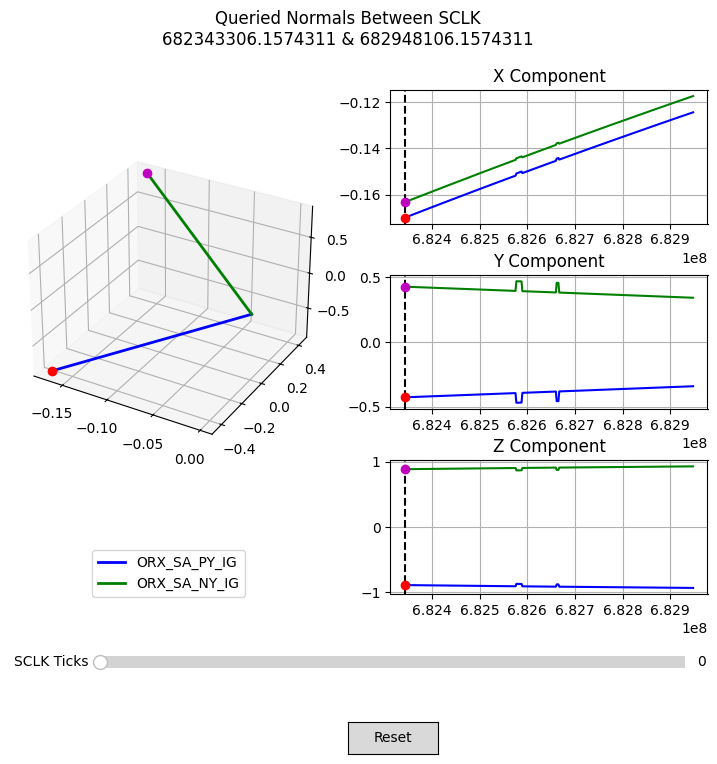

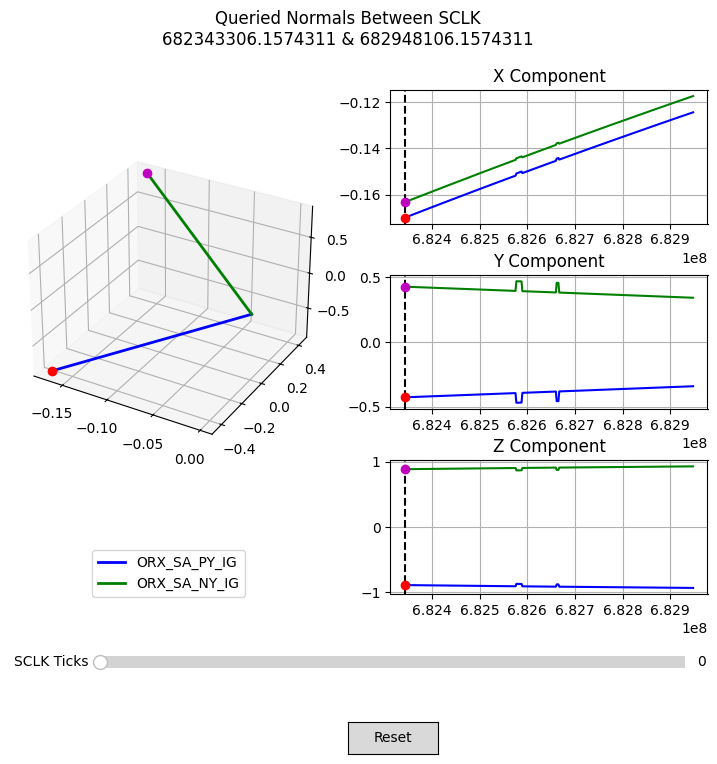

In [6]:
%matplotlib inline
# NOTE: rerun static version of the plot so that it displays for online tutorial 
supp.plotting.plot_normals(normals, times)

### Static Normals at a Single Epoch

`nPlateModel.get_all_normals(epoch, sc_id)` returns normals for **all** panels —
both fixed body-frame plates and CK-driven plates — resolved into the inertial frame
at a single epoch.  This is the call the propagator uses internally at each integration step.

In [7]:
# ── all normals (fixed + CK) at the start of the interval ────────
all_norms = n_model.get_all_normals(start, orex_id)
print("Panel normals at epoch start:")
for i, n in enumerate(all_norms):
    print(f"  Plate {i+1}: {np.array(n).round(4)}")

Panel normals at epoch start:
  Plate 1: [1 0 0]
  Plate 2: [-1  0  0]
  Plate 3: [-0.17   -0.4278 -0.8877]
  Plate 4: [-0.1633  0.4278  0.889 ]


### Attaching to a Spacecraft

Pass `n_plate_model` to `Spacecraft` to activate N-plate SRP in the force model.
`get_dependent_spice_ids()` lists every SPICE frame ID that the model depends on —
useful for verifying all required CK/FK kernels are loaded before propagation.

In [8]:
# ── attach N-plate model to spacecraft ────────────────────────────
orex = scb.Spacecraft(
    'OSIRIS-REx', -64,
    scb.ArrayWUnits(0, kg),
    n_plate_model=n_model,
)

print("Spacecraft SPICE IDs required by the N-plate model:")
print(orex.get_dependent_spice_ids())

Spacecraft SPICE IDs required by the N-plate model:
{'instruments': [], 'plates': [-64017, -64027]}


---
## 2. Spacecraft Attitude

`Spacecraft.get_attitude(frame, et)` queries the C-kernel and returns the orientation
of the spacecraft body frame as a unit quaternion $[q_0,\, q_1,\, q_2,\, q_3]$ at the
given epoch.  This wraps the underlying SPICE `ckgpav` / `m2q` calls and expresses
the result in the requested inertial frame.

The example below extracts the quaternion history for OSIRIS-REx over a five-day window
and plots all four components.

In [9]:
# ── attitude query over a 5-day window ───────────────────────────
et_start = scb.SpiceManager.str2et("2021 AUG 17 12:00:00 UTC")
et_end   = scb.SpiceManager.str2et("2021 AUG 22 08:00:00 UTC")
step_sec = 20                                          # sample every 20 s

et_arr = np.arange(et_start, et_end, step_sec)

# reuse the spacecraft defined in §1 (orex already has the N-plate model)
attitudes = [orex.get_attitude(J2000, et) for et in et_arr]
attitudes = np.array(attitudes)                        # shape: (N, 4)

print(f"Queried {len(attitudes)} attitude epochs")
print(f"First quaternion  [q0 q1 q2 q3] : {attitudes[0].round(6)}")
print(f"Norm check (should be 1.0)       : {np.linalg.norm(attitudes[0]):.8f}")

Queried 20880 attitude epochs
First quaternion  [q0 q1 q2 q3] : [ 0.737827  0.636258 -0.212256  0.075728]
Norm check (should be 1.0)       : 1.00000000
